## Problem Statement
This project aims to predict 30-day hospital readmission for diabetic patients using patient and encounter-level healthcare data. The task is a binary classification problem, with the goal of identifying patients at higher risk of early readmission.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
from sklearn.inspection import permutation_importance


The main dataset contains hospital encounters for diabetic patients, and the mapping file is used to translate some coded administrative variables into more interpretable descriptions.

Inspecting the raw structure of the data before cleaning or feature engineering.

In [2]:
DATA_PATH = Path("diabetic_data.csv")
MAP_PATH = Path("IDS_mapping.csv")

TARGET_COL = "readmitted"
POSITIVE_CLASS = "<30"
GROUP_COL = "patient_nbr"

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_SPLITS = 5
MIN_CATEGORY_COUNT = 50

DROP_HIGH_MISSING_COLS = ["weight", "payer_code", "medical_specialty"]
DROP_ID_COLS = ["encounter_id", "patient_nbr", "readmitted"]
NON_READMITTABLE_IDS = [11, 13, 14, 19, 20, 21]

In [3]:
df_raw = pd.read_csv(DATA_PATH)
ids_raw = pd.read_csv(MAP_PATH)

print("Main dataset shape:", df_raw.shape)
print("Mapping file shape:", ids_raw.shape)

display(df_raw.head())
display(ids_raw.head(15))

Main dataset shape: (101766, 50)
Mapping file shape: (67, 2)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


## Parse the ID mapping file

The main dataset contains administrative columns such as `admission_type_id`, `discharge_disposition_id`, and `admission_source_id`, but these are stored as numeric codes. In this step, I parse the separate mapping file into Python dictionaries so I can translate those coded values into more interpretable labels.

This is useful for EDA because raw numeric IDs are difficult to interpret directly. Adding readable descriptions makes it easier to understand the distribution of admission and discharge categories before modeling.

In [4]:
def parse_ids_mapping(mapping_df: pd.DataFrame):
    maps = {
        "admission_type_id": {},
        "discharge_disposition_id": {},
        "admission_source_id": {},
    }

    left_col = mapping_df.columns[0]
    right_col = mapping_df.columns[1]
    current_key = "admission_type_id"

    for _, row in mapping_df.iterrows():
        left = row[left_col]
        right = row[right_col]

        if pd.isna(left) and pd.isna(right):
            continue

        left_str = str(left).strip()

        if left_str in maps:
            current_key = left_str
            continue

        try:
            code = int(float(left))
            maps[current_key][code] = str(right).strip() if pd.notna(right) else np.nan
        except Exception:
            continue

    return maps

id_maps = parse_ids_mapping(ids_raw)

print(id_maps.keys())
print(list(id_maps["admission_type_id"].items())[:10])

dict_keys(['admission_type_id', 'discharge_disposition_id', 'admission_source_id'])
[(1, 'Emergency'), (2, 'Urgent'), (3, 'Elective'), (4, 'Newborn'), (5, 'Not Available'), (6, nan), (7, 'Trauma Center'), (8, 'Not Mapped')]


## Create the EDA dataframe

Here I create a separate copy of the raw dataset for exploratory analysis and replace `"?"` with proper missing values. I also map the coded administrative variables to readable descriptions using the dictionaries created from the mapping file.

I keep this EDA version separate from the later modeling dataframe so I can explore the raw data structure first without mixing EDA steps with modeling-specific preprocessing.

In [5]:
eda_df = df_raw.copy().replace("?", np.nan)

for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    if col in eda_df.columns and col in id_maps:
        eda_df[f"{col}_desc"] = eda_df[col].map(id_maps[col])

print("EDA dataframe shape:", eda_df.shape)
display(eda_df.head())

EDA dataframe shape: (101766, 53)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_id_desc,discharge_disposition_id_desc,admission_source_id_desc
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,NaN,Not Mapped,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,Emergency,Discharged to home,Emergency Room
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room


Rows: 101766
Columns: 53


,count,percent
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


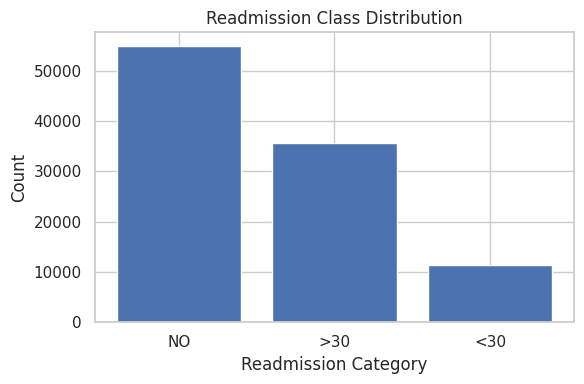

In [6]:
print("Rows:", eda_df.shape[0])
print("Columns:", eda_df.shape[1])

target_counts = eda_df[TARGET_COL].value_counts(dropna=False)
target_pct = eda_df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100

display(pd.DataFrame({
    "count": target_counts,
    "percent": target_pct.round(2),
}))

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.xlabel("Readmission Category")
plt.ylabel("Count")
plt.title("Readmission Class Distribution")
plt.tight_layout()
plt.show()

,missing_fraction
weight,0.968585
max_glu_serum,0.947468
A1Cresult,0.832773
medical_specialty,0.490822
payer_code,0.395574
admission_source_id_desc,0.066633
admission_type_id_desc,0.051992
discharge_disposition_id_desc,0.036269
race,0.022336
diag_3,0.013983


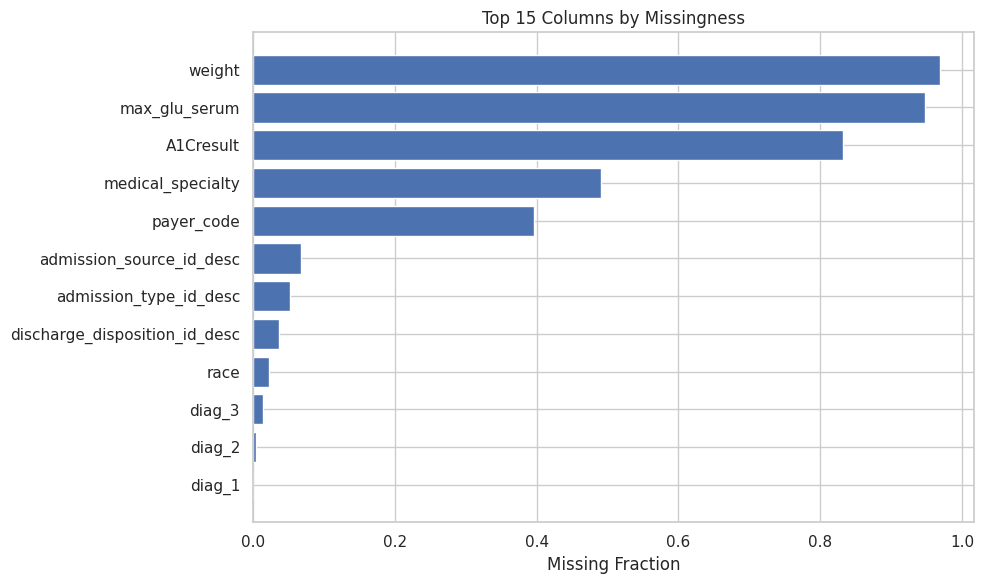

In [7]:
missing_df = (
    eda_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)

display(missing_df.head(15))

plt.figure(figsize=(10, 6))
top_missing = missing_df[missing_df["missing_fraction"] > 0].head(15).sort_values("missing_fraction")
plt.barh(top_missing.index, top_missing["missing_fraction"])
plt.xlabel("Missing Fraction")
plt.title("Top 15 Columns by Missingness")
plt.tight_layout()
plt.show()

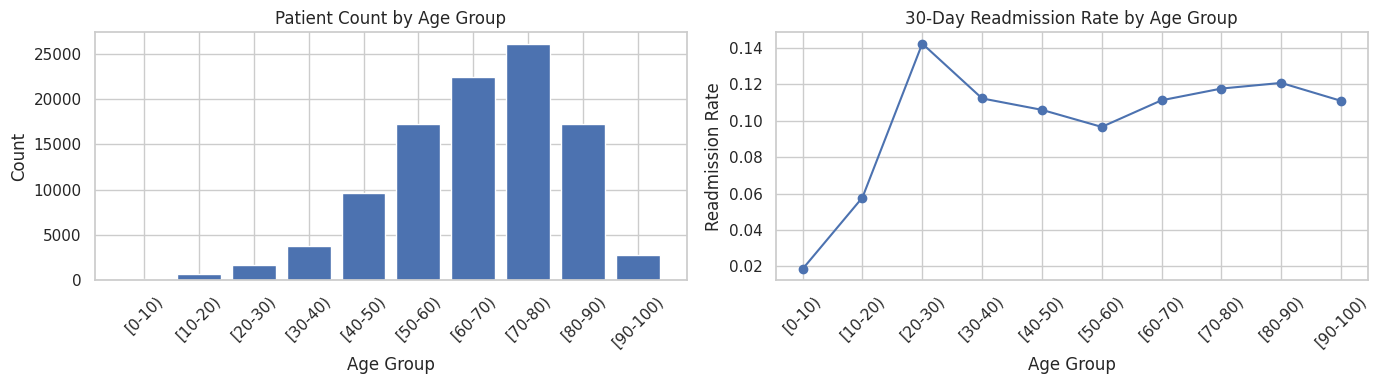

In [8]:
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]
eda_work = eda_df.copy()
eda_work["target_30"] = (eda_work[TARGET_COL] == POSITIVE_CLASS).astype(int)

age_counts = eda_work["age"].value_counts().reindex(age_order)
age_rate = eda_work.groupby("age")["target_30"].mean().reindex(age_order)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].bar(age_counts.index, age_counts.values)
ax[0].set_title("Patient Count by Age Group")
ax[0].set_xlabel("Age Group")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis="x", rotation=45)

ax[1].plot(age_rate.index, age_rate.values, marker="o")
ax[1].set_title("30-Day Readmission Rate by Age Group")
ax[1].set_xlabel("Age Group")
ax[1].set_ylabel("Readmission Rate")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Explore age patterns in relation to 30-day readmission

Here I create a binary version of the target called `target_30`, where 1 means readmitted within 30 days and 0 means otherwise. I then summarize how 30-day readmission varies across the original age buckets.

I do this because age is a clinically meaningful variable, and I want to check whether readmission risk changes across age groups before feature engineering. This also motivates the later creation of the numeric `age_midpoint` feature.

,count,mean
gender,,
Female,54708,0.1125
Male,47055,0.1106
Unknown/Invalid,3,0.0000


,count,mean
race,,
Caucasian,76099,0.1129
AfricanAmerican,19210,0.1122
Hispanic,2037,0.1041
Other,1506,0.0963
Asian,641,0.1014


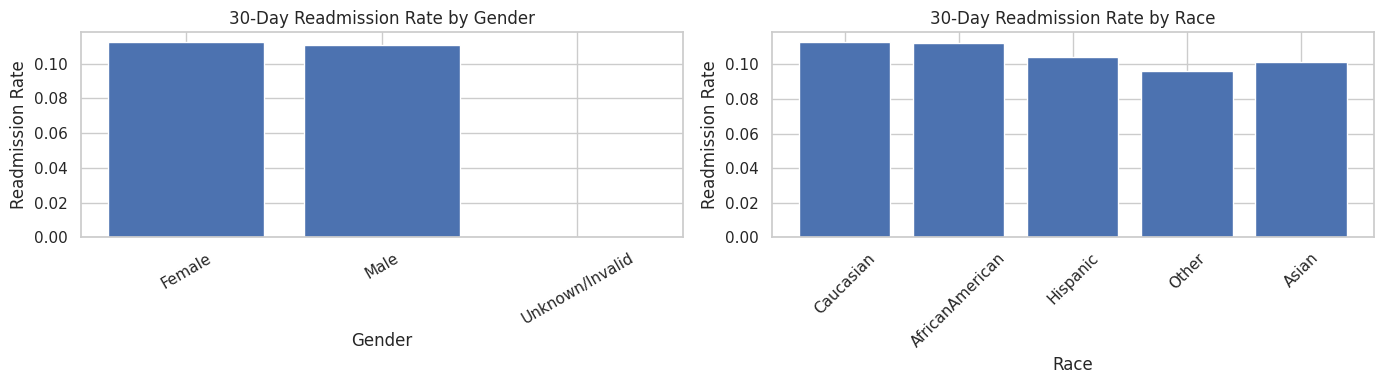

In [9]:
gender_summary = eda_work.groupby("gender")["target_30"].agg(["count", "mean"]).sort_values("count", ascending=False)
race_summary = eda_work.groupby("race")["target_30"].agg(["count", "mean"]).sort_values("count", ascending=False)

display(gender_summary.round(4))
display(race_summary.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].bar(gender_summary.index.astype(str), gender_summary["mean"])
ax[0].set_title("30-Day Readmission Rate by Gender")
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Readmission Rate")
ax[0].tick_params(axis="x", rotation=30)

top_races = race_summary.head(10)
ax[1].bar(top_races.index.astype(str), top_races["mean"])
ax[1].set_title("30-Day Readmission Rate by Race")
ax[1].set_xlabel("Race")
ax[1].set_ylabel("Readmission Rate")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

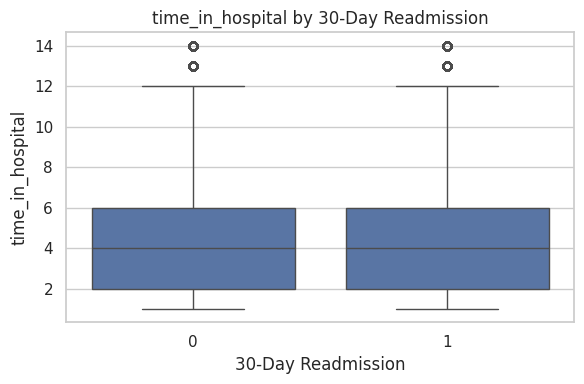

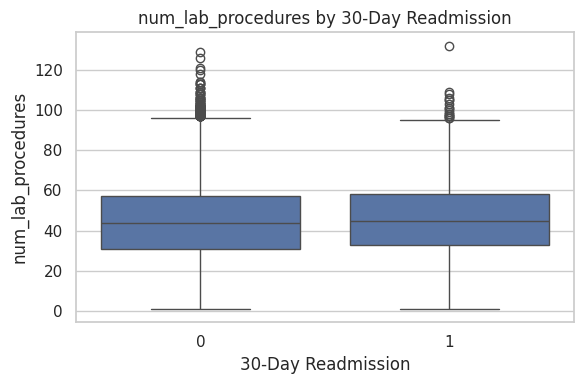

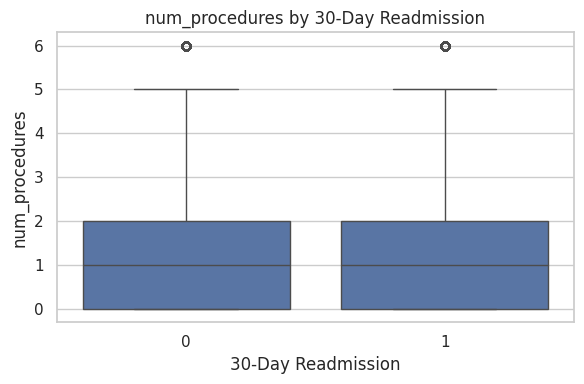

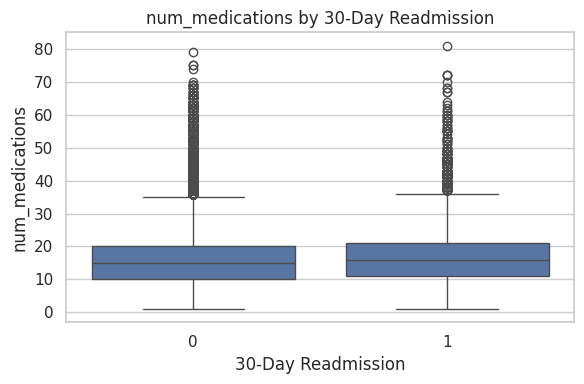

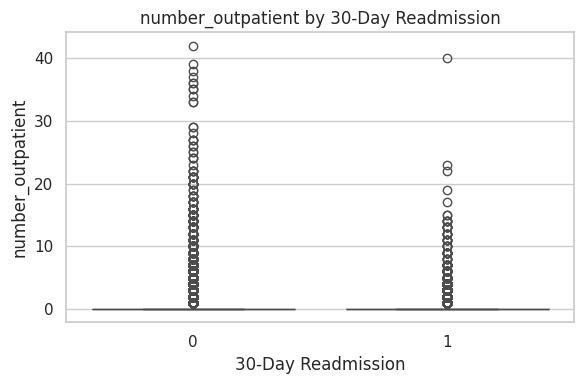

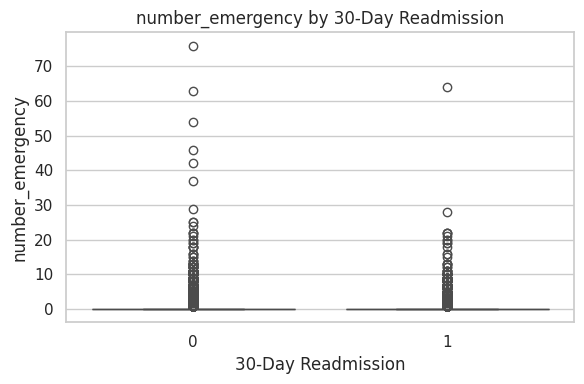

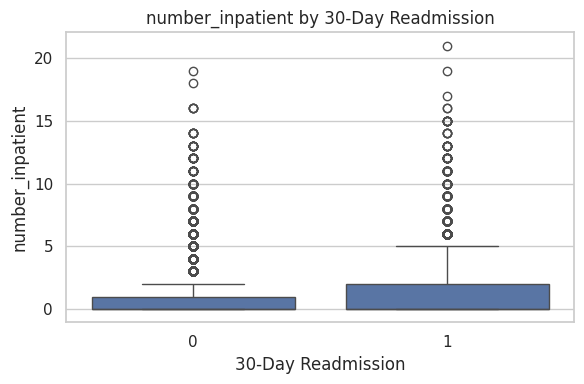

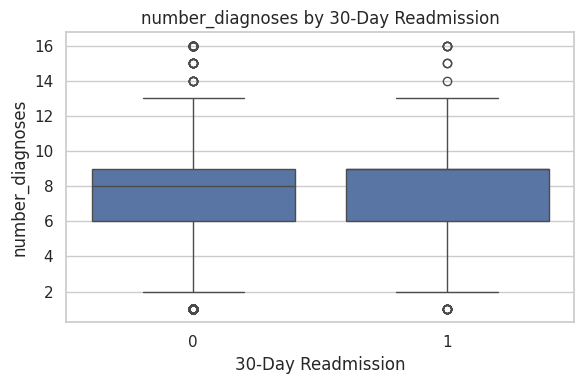

In [10]:
plot_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

for col in plot_cols:
    if col in eda_work.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=eda_work, x="target_30", y=col)
        plt.title(f"{col} by 30-Day Readmission")
        plt.xlabel("30-Day Readmission")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

## Examine correlations among numeric variables

Here I compute a correlation matrix for selected numeric features. This helps me understand how utilization-related variables, medication counts, procedure counts, and hospital stay variables relate to one another.

I use this step to get a better sense of redundancy and overlap among the numeric predictors before engineering new summary features such as total prior visits and care intensity.

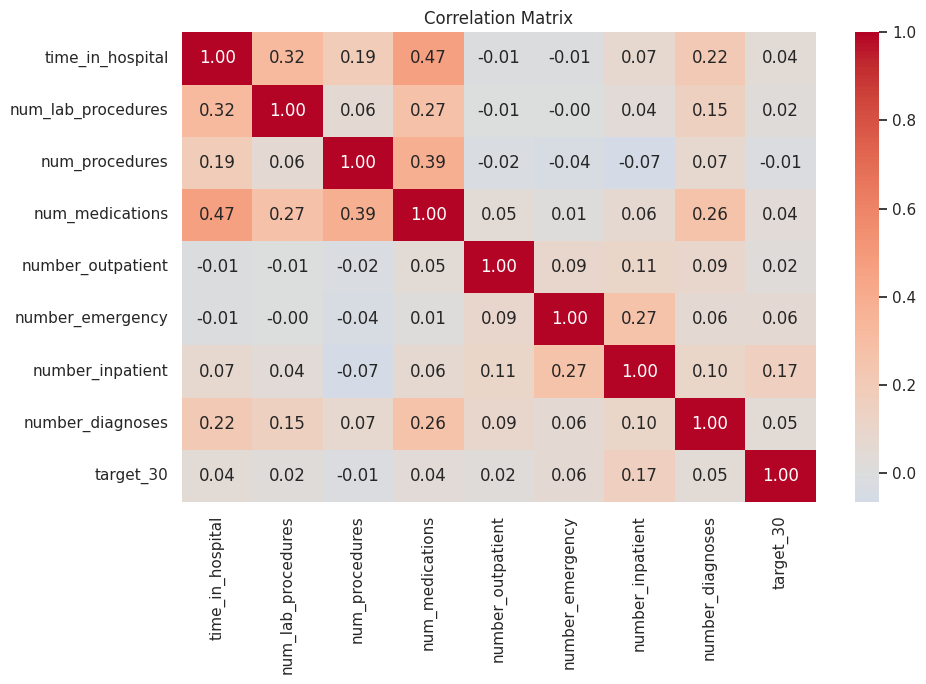

In [11]:
selected_numeric = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

available_cols = [c for c in selected_numeric + ["target_30"] if c in eda_work.columns]
corr_matrix = eda_work[available_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Clean the data and engineer modeling features

This cell prepares the modeling dataset by replacing `"?"` with missing values, removing non-readmittable discharge cases, and dropping highly incomplete columns such as `weight`, `payer_code`, and `medical_specialty`.

It also simplifies the diagnosis fields, creates the binary target (`<30` vs. all others), converts age ranges into `age_midpoint`, and engineers several utilization-based features such as `total_prior_visits`, `had_prior_visit`, `had_prior_inpatient`, `care_intensity`, and `diagnoses_per_day`. In addition, `log1p` is applied to skewed count variables, and administrative ID columns are converted to strings so they are handled as categorical variables during preprocessing.

In [12]:
def simplify_diag_code(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "":
        return np.nan
    if x.startswith("V"):
        return "V"
    if x.startswith("E"):
        return "E"
    return x.split(".")[0]

def map_age_midpoint(age_bucket):
    if pd.isna(age_bucket):
        return np.nan
    age_bucket = str(age_bucket).strip()
    if age_bucket.startswith("[") and age_bucket.endswith(")"):
        left, right = age_bucket[1:-1].split("-")
        return (int(left) + int(right)) / 2
    return np.nan

def safe_log1p(x):
    return np.log1p(pd.to_numeric(x, errors="coerce").clip(lower=0))

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().replace("?", np.nan)

    df = df[df[TARGET_COL].isin(["<30", ">30", "NO"])].copy()

    if "discharge_disposition_id" in df.columns:
        df = df[~df["discharge_disposition_id"].isin(NON_READMITTABLE_IDS)].copy()

    cols_to_drop = [c for c in DROP_HIGH_MISSING_COLS if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    for col in ["diag_1", "diag_2", "diag_3"]:
        if col in df.columns:
            df[col] = df[col].apply(simplify_diag_code)

    df["target"] = (df[TARGET_COL] == POSITIVE_CLASS).astype(int)

    if "age" in df.columns:
        df["age_midpoint"] = df["age"].apply(map_age_midpoint)

    if {"number_outpatient", "number_emergency", "number_inpatient"}.issubset(df.columns):
        df["total_prior_visits"] = (
            df["number_outpatient"].fillna(0)
            + df["number_emergency"].fillna(0)
            + df["number_inpatient"].fillna(0)
        )
        df["had_prior_visit"] = (df["total_prior_visits"] > 0).astype(int)
        df["had_prior_inpatient"] = (df["number_inpatient"].fillna(0) > 0).astype(int)

    if {"num_lab_procedures", "num_procedures", "num_medications"}.issubset(df.columns):
        df["care_intensity"] = (
            df["num_lab_procedures"].fillna(0)
            + df["num_procedures"].fillna(0)
            + df["num_medications"].fillna(0)
        )

    if "number_diagnoses" in df.columns and "time_in_hospital" in df.columns:
        df["diagnoses_per_day"] = (
            df["number_diagnoses"] / df["time_in_hospital"].replace(0, np.nan)
        )

    for col in [
        "time_in_hospital",
        "num_lab_procedures",
        "num_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "number_diagnoses",
        "total_prior_visits",
        "care_intensity",
    ]:
        if col in df.columns:
            df[f"{col}_log1p"] = safe_log1p(df[col])

    for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
        if col in df.columns:
            df[col] = df[col].astype("Int64").astype("string")

    return df

model_df = engineer_features(df_raw)

print("Modeling shape:", model_df.shape)
print("Binary target rate:", round(model_df["target"].mean(), 4))
display(model_df.head())

Modeling shape: (99343, 64)
Binary target rate: 0.1139


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target,age_midpoint,total_prior_visits,had_prior_visit,had_prior_inpatient,care_intensity,diagnoses_per_day,time_in_hospital_log1p,num_lab_procedures_log1p,num_procedures_log1p,num_medications_log1p,number_outpatient_log1p,number_emergency_log1p,number_inpatient_log1p,number_diagnoses_log1p,total_prior_visits_log1p,care_intensity_log1p
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0,5.0,0,0,0,42,1.0,0.693147,3.737670,0.000000,0.693147,0.000000,0.0,0.000000,0.693147,0.000000,3.761200
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0,15.0,0,0,0,77,3.0,1.386294,4.094345,0.000000,2.944439,0.000000,0.0,0.000000,2.302585,0.000000,4.356709
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0,25.0,3,1,1,29,3.0,1.098612,2.484907,1.791759,2.639057,1.098612,0.0,0.693147,1.945910,1.386294,3.401197
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0,35.0,0,0,0,61,3.5,1.098612,3.806662,0.693147,2.833213,0.000000,0.0,0.000000,2.079442,0.000000,4.127134
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0,45.0,0,0,0,59,5.0,0.693147,3.951244,0.000000,2.197225,0.000000,0.0,0.000000,1.791759,0.000000,4.094345


In [13]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(
    splitter.split(model_df, y=model_df["target"], groups=model_df[GROUP_COL])
)

train_df = model_df.iloc[train_idx].reset_index(drop=True)
test_df = model_df.iloc[test_idx].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

shared_patients = set(train_df[GROUP_COL]).intersection(set(test_df[GROUP_COL]))
print("Shared patients across train/test:", len(shared_patients))

Train shape: (79541, 64)
Test shape: (19802, 64)
Shared patients across train/test: 0


In [14]:
X_train = train_df.drop(columns=DROP_ID_COLS + ["target"]).copy()
y_train = train_df["target"].copy()
groups_train = train_df[GROUP_COL].copy()

X_test = test_df.drop(columns=DROP_ID_COLS + ["target"]).copy()
y_test = test_df["target"].copy()

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, min_count=50, other_label="Other"):
        self.min_count = min_count
        self.other_label = other_label

    def fit(self, X, y=None):
        X = X.copy()
        self.categorical_cols_ = X.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
        self.keep_values_ = {}

        for col in self.categorical_cols_:
            freq = X[col].value_counts(dropna=False)
            self.keep_values_[col] = set(freq[freq >= self.min_count].index.tolist())

        return self

    def transform(self, X):
        X = X.copy()

        for col in getattr(self, "categorical_cols_", []):
            keep_vals = self.keep_values_.get(col, set())
            keep_mask = X[col].isin(keep_vals) | X[col].isna()
            X[col] = X[col].where(keep_mask, self.other_label)

        return X

def build_preprocessor(scale_numeric=True):
    numeric_selector = make_column_selector(dtype_include=np.number)
    categorical_selector = make_column_selector(dtype_include=["object", "category", "bool", "string"])

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True))
    ]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler(with_mean=False)))

    numeric_pipeline = Pipeline(numeric_steps)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_ohe()),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_selector),
            ("cat", categorical_pipeline, categorical_selector),
        ],
        sparse_threshold=1.0,
    )

def make_model_pipeline(estimator, scale_numeric=True):
    return Pipeline([
        ("rare_grouper", RareCategoryGrouper(min_count=MIN_CATEGORY_COUNT)),
        ("preprocessor", build_preprocessor(scale_numeric=scale_numeric)),
        ("drop_constant", VarianceThreshold(threshold=0.0)),
        ("model", estimator),
    ])

def get_continuous_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1], "probability"
    if hasattr(model, "decision_function"):
        return model.decision_function(X), "margin"
    preds = model.predict(X).astype(float)
    return preds, "label"


def get_oof_scores(model, X, y, groups, n_splits=None):
    if n_splits is None:
        n_splits = CV_SPLITS

    gkf = GroupKFold(n_splits=n_splits)
    oof_scores = np.zeros(len(y), dtype=float)
    score_type_final = None

    for tr_idx, val_idx in gkf.split(X, y, groups):
        X_tr = X.iloc[tr_idx]
        y_tr = y.iloc[tr_idx]
        X_val = X.iloc[val_idx]

        fitted = clone(model)
        fitted.fit(X_tr, y_tr)

        fold_scores, score_type = get_continuous_scores(fitted, X_val)
        oof_scores[val_idx] = fold_scores
        score_type_final = score_type

    return oof_scores, score_type_final

def find_best_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    if len(thresholds) == 0:
        return 0.5, pd.DataFrame()

    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)

    threshold_df = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
        "f1": f1,
    }).sort_values(["f1", "precision", "recall"], ascending=False).reset_index(drop=True)

    best_threshold = float(threshold_df.iloc[0]["threshold"])
    return best_threshold, threshold_df

In [15]:
models = {
    "dummy_baseline": make_model_pipeline(
        DummyClassifier(strategy="prior"),
        scale_numeric=False,
    ),
    "logistic_regression": make_model_pipeline(
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
        scale_numeric=True,
    ),
    "decision_tree": make_model_pipeline(
        DecisionTreeClassifier(
            max_depth=10,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
        ),
        scale_numeric=False,
    ),
    "random_forest": make_model_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        scale_numeric=False,
    ),
    "gradient_boosting": make_model_pipeline(
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
        scale_numeric=False,
    ),
    "xgboost": make_model_pipeline(
        XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        scale_numeric=False,
    ),
    "lightgbm": make_model_pipeline(
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        scale_numeric=False,
    ),
    "knn": make_model_pipeline(
        KNeighborsClassifier(
            n_neighbors=15,
        ),
        scale_numeric=True,
    ),
    "linear_svm": make_model_pipeline(
        LinearSVC(
            C=1.0,
            max_iter=5000,
            random_state=RANDOM_STATE,
        ),
        scale_numeric=True,
    ),
    "mlp": make_model_pipeline(
        MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            max_iter=300,
            random_state=RANDOM_STATE,
        ),
        scale_numeric=True,
    ),
}

## Compare models with grouped 5-fold cross-validation

This section evaluates all candidate models using **5-fold GroupKFold cross-validation**, grouped by patient.

Since repeated patients exist in the dataset, grouped cross-validation ensures that all encounters from the same patient remain in the same fold. This avoids patient-level leakage not only in the train/test split, but also during model comparison.

The main model-selection metric is **PR-AUC** because the positive class is relatively rare. In this dataset, a model can achieve high accuracy by mostly predicting the majority class, so PR-AUC is more informative for evaluating how well the model identifies the minority `<30` readmission cases.


In [16]:
gkf = GroupKFold(n_splits=CV_SPLITS)

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "accuracy": "accuracy",
}

cv_rows = []

for model_name, model in models.items():
    scores = cross_validate(
        clone(model),
        X_train,
        y_train,
        groups=groups_train,
        cv=gkf,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )

    cv_rows.append({
        "model": model_name,
        "pr_auc_mean": scores["test_pr_auc"].mean(),
        "pr_auc_std": scores["test_pr_auc"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "accuracy_mean": scores["test_accuracy"].mean(),
    })

cv_mean_df = pd.DataFrame(cv_rows).sort_values(
    "pr_auc_mean", ascending=False
).reset_index(drop=True)

print("Cross-validation results:")
display(cv_mean_df.round(4))

Cross-validation results:


,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,precision_mean,recall_mean,accuracy_mean
0,xgboost,0.2275,0.0057,0.6719,0.0107,0.0177,0.6240,0.0090,0.8860
1,lightgbm,0.2205,0.0046,0.6630,0.0090,0.2768,0.1865,0.5369,0.6792
2,gradient_boosting,0.2197,0.0049,0.6664,0.0084,0.0123,0.5188,0.0062,0.8857
3,linear_svm,0.2152,0.0034,0.6570,0.0069,0.0144,0.5167,0.0073,0.8857
4,random_forest,0.2138,0.0057,0.6638,0.0081,0.1468,0.3248,0.0949,0.8739
5,logistic_regression,0.2108,0.0040,0.6569,0.0072,0.0285,0.4716,0.0147,0.8854
6,decision_tree,0.1903,0.0084,0.6386,0.0108,0.0564,0.2984,0.0312,0.8807
7,knn,0.1597,0.0051,0.5912,0.0058,0.0268,0.4544,0.0138,0.8853
8,mlp,0.1436,0.0025,0.5635,0.0109,0.1580,0.1610,0.1552,0.8108
9,dummy_baseline,0.1144,0.0021,0.5000,0.0000,0.0000,0.0000,0.0000,0.8856


In [17]:
compact_comparison_table = cv_mean_df[[
    "model", "pr_auc_mean", "roc_auc_mean", "f1_mean",
    "precision_mean", "recall_mean", "accuracy_mean"
]].copy()

compact_comparison_table.columns = [
    "model", "cv_pr_auc", "cv_roc_auc", "cv_f1",
    "cv_precision", "cv_recall", "cv_accuracy"
]

print("Compact model comparison table:")
display(compact_comparison_table.round(4))

Compact model comparison table:


,model,cv_pr_auc,cv_roc_auc,cv_f1,cv_precision,cv_recall,cv_accuracy
0,xgboost,0.2275,0.6719,0.0177,0.6240,0.0090,0.8860
1,lightgbm,0.2205,0.6630,0.2768,0.1865,0.5369,0.6792
2,gradient_boosting,0.2197,0.6664,0.0123,0.5188,0.0062,0.8857
3,linear_svm,0.2152,0.6570,0.0144,0.5167,0.0073,0.8857
4,random_forest,0.2138,0.6638,0.1468,0.3248,0.0949,0.8739
5,logistic_regression,0.2108,0.6569,0.0285,0.4716,0.0147,0.8854
6,decision_tree,0.1903,0.6386,0.0564,0.2984,0.0312,0.8807
7,knn,0.1597,0.5912,0.0268,0.4544,0.0138,0.8853
8,mlp,0.1436,0.5635,0.1580,0.1610,0.1552,0.8108
9,dummy_baseline,0.1144,0.5000,0.0000,0.0000,0.0000,0.8856


## Tune XGBoost with randomized search

Since XGBoost was one of the strongest models in the initial comparison, I tune it using `RandomizedSearchCV`.

The search explores key hyperparameters such as:
- `n_estimators`
- `max_depth`
- `learning_rate`
- `subsample`
- `colsample_bytree`
- `min_child_weight`
- `gamma`
- `reg_alpha`
- `reg_lambda`
- `scale_pos_weight`

I include `scale_pos_weight` because the target is imbalanced, so the search can test whether explicit class weighting helps. The tuning is scored using `average_precision`, which matches the project's main metric.

In [18]:
imbalance_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_search = RandomizedSearchCV(
    estimator=make_model_pipeline(
        XGBClassifier(
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        scale_numeric=False,
    ),
    param_distributions={
        "model__n_estimators": [200, 300, 400, 500],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5, 7],
        "model__gamma": [0, 0.1, 0.3, 0.5],
        "model__reg_alpha": [0, 0.01, 0.1, 1.0],
        "model__reg_lambda": [1.0, 2.0, 5.0, 10.0],
        "model__scale_pos_weight": [1.0, float(round(imbalance_ratio, 2))],
    },
    n_iter=20,
    scoring="average_precision",
    cv=gkf,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

xgb_search.fit(X_train, y_train, groups=groups_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)
print("Best XGBoost CV PR-AUC:", round(xgb_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost parameters:
{'model__subsample': 0.9, 'model__scale_pos_weight': 1.0, 'model__reg_lambda': 2.0, 'model__reg_alpha': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.5, 'model__colsample_bytree': 0.8}
Best XGBoost CV PR-AUC: 0.2271


## Why the untuned XGBoost model was kept

The tuned XGBoost model did not improve cross-validated PR-AUC over the untuned version. This suggests that the untuned model was already a strong baseline, and the randomized search did not find a clearly better configuration. Therefore, I kept the untuned XGBoost model as the final model, since model selection should follow the actual validation results.

In [19]:
xgb_untuned = cv_mean_df.loc[
    cv_mean_df["model"] == "xgboost", "pr_auc_mean"
].values[0]

tuning_comparison = pd.DataFrame([
    {
        "model": "xgboost_untuned",
        "cv_pr_auc": xgb_untuned,
    },
    {
        "model": "xgboost_tuned",
        "cv_pr_auc": xgb_search.best_score_,
    }
])

print("Untuned vs Tuned XGBoost:")
display(tuning_comparison.round(4))

Untuned vs Tuned XGBoost:


,model,cv_pr_auc
0,xgboost_untuned,0.2275
1,xgboost_tuned,0.2271


In [20]:
candidate_models = {f"{name}_untuned": model for name, model in models.items()}
candidate_models["xgboost_tuned"] = xgb_search.best_estimator_

candidate_scores = {
    f"{name}_untuned": cv_mean_df.loc[
        cv_mean_df["model"] == name, "pr_auc_mean"
    ].values[0]
    for name in models.keys()
}
candidate_scores["xgboost_tuned"] = xgb_search.best_score_

final_model_name = max(candidate_scores, key=candidate_scores.get)
final_model = clone(candidate_models[final_model_name])

print("Selected final model:", final_model_name)
print("Selected based on best CV PR-AUC:", round(candidate_scores[final_model_name], 4))

Selected final model: xgboost_untuned
Selected based on best CV PR-AUC: 0.2275


In [21]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('rare_grouper', RareCategoryGrouper()),
                ('preprocessor',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x77ff1cf7d970>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_va...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Tune the classification threshold using out-of-fold training predictions

After selecting the final model (XGBoost Untuned), I fit it and then generate out-of-fold scores on the training set using grouped cross-validation.

The model produces continuous scores, not just final class labels. I then search over thresholds and choose the threshold that gives the best **F1 score** on the out-of-fold training predictions.


The default threshold is not always appropriate, especially in an imbalanced problem. A model can rank patients well but still predict too few positives at the default cutoff. By tuning the threshold on out-of-fold training predictions, I improve the balance between precision and recall without using the test set for threshold selection.

In [22]:
oof_scores, oof_score_type = get_oof_scores(
    final_model,
    X_train,
    y_train,
    groups_train,
    n_splits=CV_SPLITS,
)

best_threshold, threshold_df = find_best_threshold(y_train, oof_scores)

print("Selected threshold from out-of-fold training predictions:", round(best_threshold, 4))
print("Top threshold candidates:")
display(threshold_df.head(10).round(4))
print("OOF PR-AUC on training set:", round(average_precision_score(y_train, oof_scores), 4))

Selected threshold from out-of-fold training predictions: 0.1354
Top threshold candidates:


,threshold,precision,recall,f1
0,0.1354,0.2056,0.4723,0.2865
1,0.1354,0.2056,0.4723,0.2865
2,0.1354,0.2056,0.4723,0.2865
3,0.1354,0.2055,0.4725,0.2865
4,0.1358,0.2059,0.4707,0.2865
5,0.1354,0.2056,0.4723,0.2864
6,0.1354,0.2055,0.4725,0.2864
7,0.1352,0.2053,0.4735,0.2864
8,0.1358,0.2059,0.4707,0.2864
9,0.1357,0.2058,0.4708,0.2864


OOF PR-AUC on training set: 0.2266


In [23]:
def compute_metrics_from_scores(y_true, scores, threshold, score_type):
    if score_type == "label":
        preds = scores.astype(int)
        return {
            "accuracy": accuracy_score(y_true, preds),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0),
            "roc_auc": float("nan"),
            "pr_auc": float("nan"),
        }

    preds = (scores >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
    }
test_scores, test_score_type = get_continuous_scores(final_model, X_test)

if test_score_type == "label":
    final_pred = test_scores.astype(int)
else:
    final_pred = (test_scores >= best_threshold).astype(int)

final_results = compute_metrics_from_scores(
    y_test,
    test_scores,
    best_threshold,
    test_score_type,
)

print("Final test-set results:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Final test-set results:
accuracy: 0.7321
precision: 0.1987
recall: 0.4594
f1: 0.2774
roc_auc: 0.6698
pr_auc: 0.2304


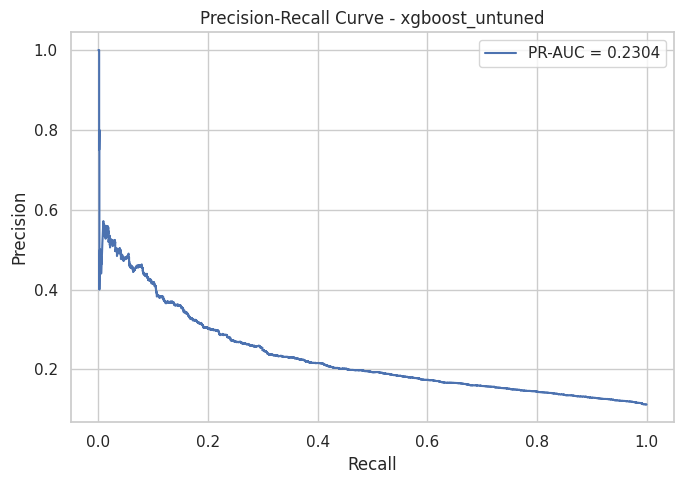

In [24]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, test_scores)
test_pr_auc = average_precision_score(y_test, test_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {test_pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - {final_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

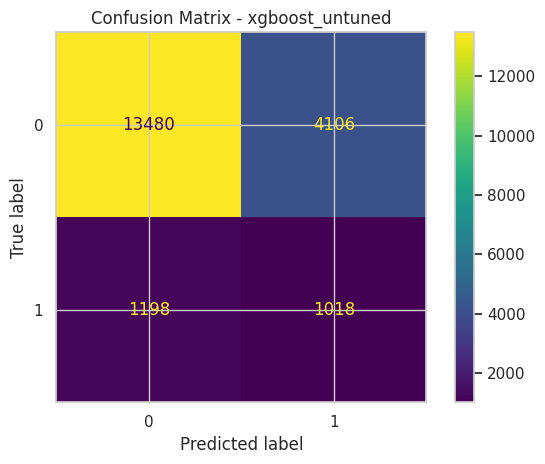

In [25]:
cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {final_model_name}")
plt.tight_layout()
plt.show()

## Calibration Analysis

The calibration curve compares predicted probabilities with observed outcome frequencies, while the Brier score provides a summary measure of probabilistic accuracy.

Brier Score: 0.09440636571855336


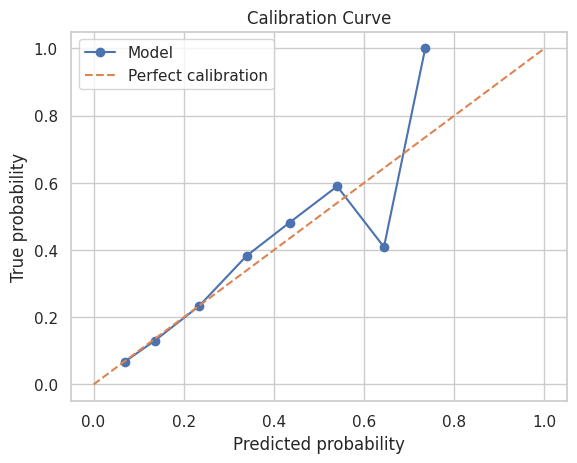

In [26]:
# get probabilities
y_proba = final_model.predict_proba(X_test)[:, 1]

# calibration
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

print("Brier Score:", brier_score_loss(y_test, y_proba))

plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0, 1], [0, 1], linestyle='--', label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

The calibration curve shows that the model is reasonably well calibrated in the lower probability range (below ~0.4), where predicted probabilities closely follow the diagonal. This is important because most patients fall into the low-risk region in this imbalanced dataset.

However, at higher predicted probabilities, the model becomes less stable, with some deviations from the ideal calibration line. This suggests that while the model is effective at ranking patients by risk, its probability estimates for high-risk cases may be less reliable.

The Brier score of 0.0944 indicates acceptable overall probabilistic accuracy, though there is still room for improvement. Overall, the model provides reasonably calibrated probabilities, but should be interpreted cautiously at higher risk levels.

### Threshold Tradeoff Analysis

Because the final model is used in an imbalanced classification setting, the classification threshold has a strong effect on precision, recall, and F1 score. To better understand this tradeoff, I evaluate model performance across a range of thresholds on the test set.

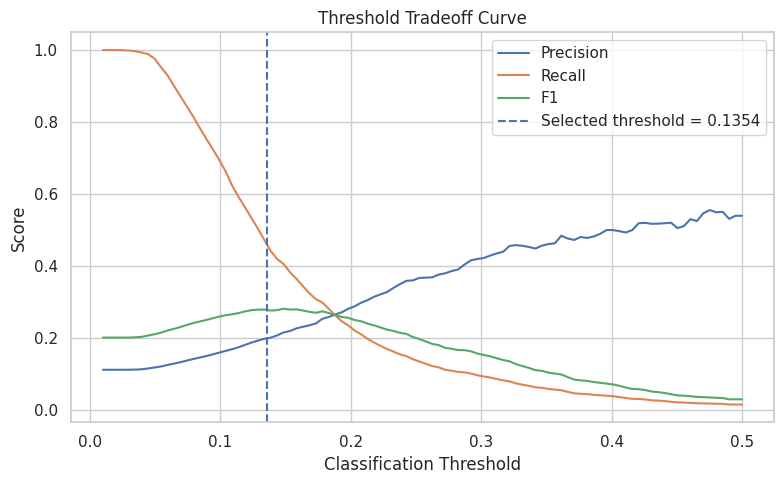

In [27]:
thresholds = np.linspace(0.01, 0.50, 100)

precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    precision_list.append(precision_score(y_test, preds, zero_division=0))
    recall_list.append(recall_score(y_test, preds, zero_division=0))
    f1_list.append(f1_score(y_test, preds, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds, f1_list, label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Selected threshold = {best_threshold:.4f}")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Tradeoff Curve")
plt.legend()
plt.tight_layout()
plt.show()

The threshold tradeoff curve shows the expected inverse relationship between precision and recall. As the threshold increases, precision improves while recall decreases, reflecting a stricter classification rule.

The F1 score reaches its peak around the selected threshold (~0.135), indicating a balanced tradeoff between precision and recall at this point. This supports the earlier threshold selection based on out-of-fold training predictions.

At lower thresholds, recall is very high but precision is low, meaning many false positives. At higher thresholds, precision improves but recall drops sharply, leading to missed high-risk patients. Therefore, the selected threshold represents a reasonable compromise for this imbalanced readmission prediction task.

In [28]:
# Build analysis dataframe
error_df = X_test.copy().reset_index(drop=True)

# Ensure y_test aligns
y_test_array = np.array(y_test)

error_df["y_true"] = y_test_array
error_df["y_proba"] = y_proba
error_df["y_pred"] = (y_proba >= best_threshold).astype(int)

# Split error types
false_positives = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)]
false_negatives = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)]

# Basic counts
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

# Show a few examples
display(false_positives.head())
display(false_negatives.head())

False Positives: 4106
False Negatives: 1198


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,age_midpoint,total_prior_visits,had_prior_visit,had_prior_inpatient,care_intensity,diagnoses_per_day,time_in_hospital_log1p,num_lab_procedures_log1p,num_procedures_log1p,num_medications_log1p,number_outpatient_log1p,number_emergency_log1p,number_inpatient_log1p,number_diagnoses_log1p,total_prior_visits_log1p,care_intensity_log1p,y_true,y_proba,y_pred
6,AfricanAmerican,Female,[50-60),3,6,2,9,37,2,19,0,0,1,250,440,403,4,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,55.0,1,1,1,58,0.444444,2.302585,3.637586,1.098612,2.995732,0.0,0.0,0.693147,1.609438,0.693147,4.077537,0,0.159850,1
18,Caucasian,Female,[70-80),6,25,7,11,88,1,16,0,0,0,250,276,581,9,NaN,>8,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,75.0,0,0,0,105,0.818182,2.484907,4.488636,0.693147,2.833213,0.0,0.0,0.000000,2.302585,0.000000,4.663439,0,0.190824,1
45,AfricanAmerican,Female,[50-60),6,25,7,9,73,1,13,0,0,0,428,250,581,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,55.0,0,0,0,87,1.000000,2.302585,4.304065,0.693147,2.639057,0.0,0.0,0.000000,2.302585,0.000000,4.477337,0,0.176136,1
65,Caucasian,Male,[60-70),6,25,7,12,67,1,24,0,0,0,250,440,427,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,65.0,0,0,0,92,0.750000,2.564949,4.219508,0.693147,3.218876,0.0,0.0,0.000000,2.302585,0.000000,4.532599,0,0.155682,1
91,AfricanAmerican,Male,[80-90),6,25,7,6,41,0,5,0,0,1,434,342,784,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,85.0,1,1,1,46,1.000000,1.945910,3.737670,0.000000,1.791759,0.0,0.0,0.693147,1.945910,0.693147,3.850148,0,0.170412,1


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,age_midpoint,total_prior_visits,had_prior_visit,had_prior_inpatient,care_intensity,diagnoses_per_day,time_in_hospital_log1p,num_lab_procedures_log1p,num_procedures_log1p,num_medications_log1p,number_outpatient_log1p,number_emergency_log1p,number_inpatient_log1p,number_diagnoses_log1p,total_prior_visits_log1p,care_intensity_log1p,y_true,y_proba,y_pred
10,Caucasian,Female,[60-70),3,3,1,3,57,1,21,0,0,0,715,250,401,6,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,65.0,0,0,0,79,2.000000,1.386294,4.060443,0.693147,3.091042,0.0,0.0,0.000000,1.945910,0.000000,4.382027,1,0.119120,0
46,Caucasian,Male,[10-20),1,1,7,2,48,1,10,0,0,1,446,277,250,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,15.0,1,1,1,59,2.500000,1.098612,3.891820,0.693147,2.397895,0.0,0.0,0.693147,1.791759,0.693147,4.094345,1,0.085692,0
49,Caucasian,Male,[50-60),6,1,1,6,64,1,11,0,0,0,250,707,403,6,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,55.0,0,0,0,76,1.000000,1.945910,4.174387,0.693147,2.484907,0.0,0.0,0.000000,1.945910,0.000000,4.343805,1,0.087956,0
67,Caucasian,Female,[80-90),6,25,7,9,39,3,19,0,0,0,562,285,427,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,85.0,0,0,0,61,1.000000,2.302585,3.688879,1.386294,2.995732,0.0,0.0,0.000000,2.302585,0.000000,4.127134,1,0.074347,0
80,AfricanAmerican,Male,[80-90),6,25,7,3,47,0,2,0,0,0,434,729,784,5,NaN,>8,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,85.0,0,0,0,49,1.666667,1.386294,3.871201,0.000000,1.098612,0.0,0.0,0.000000,1.791759,0.000000,3.912023,1,0.093559,0


The relatively high number of false positives and false negatives highlights the challenge of separating high-risk and low-risk patients, especially when many cases share similar clinical and utilization characteristics.

In [29]:
key_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

print("False Positive Means")
display(false_positives[key_cols].mean().to_frame("mean"))

print("False Negative Means")
display(false_negatives[key_cols].mean().to_frame("mean"))

print("Overall Test Set Means")
display(error_df[key_cols].mean().to_frame("mean"))

False Positive Means


,mean
time_in_hospital,5.122747
num_lab_procedures,45.608622
num_medications,17.583049
number_outpatient,0.589381
number_emergency,0.472966
number_inpatient,1.836337


False Negative Means


,mean
time_in_hospital,4.531720
num_lab_procedures,42.897329
num_medications,16.253756
number_outpatient,0.303840
number_emergency,0.095993
number_inpatient,0.209516


Overall Test Set Means


,mean
time_in_hospital,4.380719
num_lab_procedures,42.838249
num_medications,15.960610
number_outpatient,0.368094
number_emergency,0.197505
number_inpatient,0.628775


Quantitatively, false positives had the highest average prior utilization across nearly all selected features. For example, their mean number of prior inpatient visits was 1.84, compared with 0.21 for false negatives and 0.63 in the overall test set. They also had higher average emergency visits (0.47 vs. 0.10 for false negatives) and took more medications on average (17.58 vs. 16.25). This suggests the model tends to assign higher risk to patients with stronger historical utilization signals, even when they are not actually readmitted within 30 days.
By contrast, false negatives were closer to or below the overall test-set averages on most utilization features, especially prior inpatient and emergency visits. This indicates that the model is more likely to miss readmitted patients whose historical utilization patterns appear less severe.

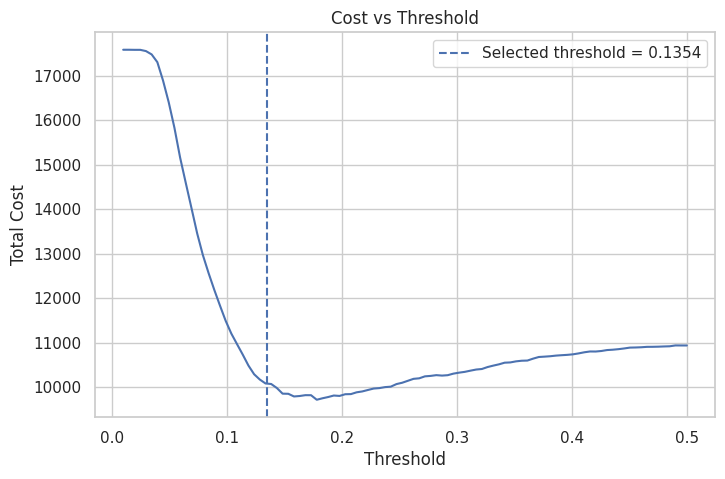

In [30]:
def cost_function(y_true, y_pred):
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    return 1 * fp + 5 * fn   # FN = 5x more costly

costs = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    costs.append(cost_function(y_test, preds))

plt.figure(figsize=(8,5))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, linestyle="--", label=f"Selected threshold = {best_threshold:.4f}")
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Cost vs Threshold")
plt.legend()
plt.show()

The cost curve shows a clear minimum around a threshold of approximately 0.15–0.18, where the total cost is lowest (just under 10,000). At very low thresholds (near 0.0), the cost is much higher (around 17,500), driven by a large number of false positives. As the threshold increases, cost decreases rapidly before reaching its minimum, after which it begins to rise again due to increasing false negatives.

The selected threshold (0.1354) lies close to this minimum-cost region, indicating that it provides a reasonable balance between false positives and false negatives under the chosen cost function. This suggests that the threshold selected based on F1 score is also near-optimal from a cost-sensitive perspective.

## Interpreting the importance results

The importance analysis shows that the strongest predictors come mainly from:
- prior inpatient history
- diagnosis information
- discharge-related information
- broader healthcare utilization patterns

This matches the earlier EDA and feature engineering choices. Patients with more prior inpatient use, heavier healthcare utilization, and more complex diagnosis patterns are more likely to be readmitted within 30 days. These results make the final model more interpretable and help connect the predictions back to meaningful clinical signals.

Top 15 model-based feature importances for xgboost_untuned:


,feature,importance
0,num__had_prior_inpatient,0.084014
1,num__number_inpatient,0.037922
2,cat__discharge_disposition_id_1,0.026870
3,cat__discharge_disposition_id_22,0.013703
4,cat__diag_1_296,0.008685
5,num__number_inpatient_log1p,0.008007
6,cat__diag_2_38,0.006768
7,cat__diag_1_V,0.006570
8,cat__discharge_disposition_id_5,0.006413
9,cat__discharge_disposition_id_2,0.005921


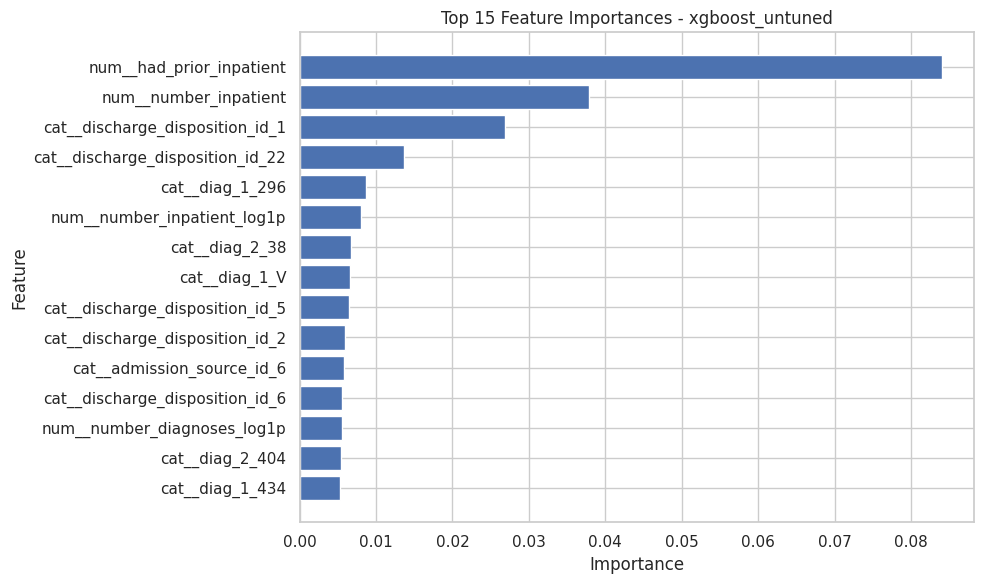

Top 15 permutation importances on test set:


,feature,importance_mean,importance_std
0,number_inpatient,0.051778,0.003261
1,discharge_disposition_id,0.039499,0.001711
2,diag_1,0.006613,0.000655
3,diag_3,0.002498,0.000513
4,diag_2,0.002022,0.000583
5,total_prior_visits,0.001767,0.001069
6,time_in_hospital,0.001730,0.000487
7,number_emergency,0.001630,0.000363
8,num_lab_procedures,0.001530,0.000771
9,care_intensity,0.001430,0.000613


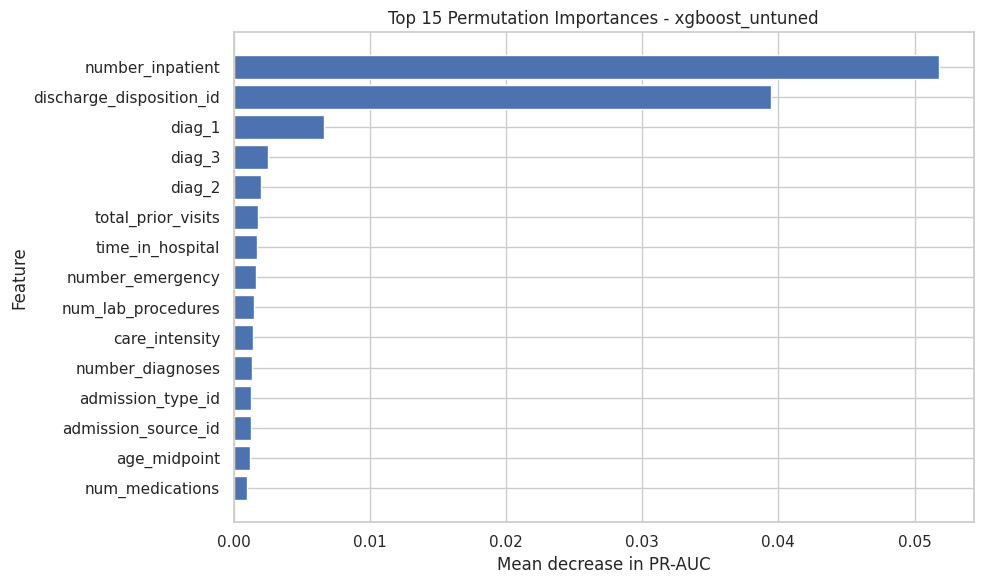

In [31]:
preprocessor = final_model.named_steps["preprocessor"]
drop_constant = final_model.named_steps["drop_constant"]
model = final_model.named_steps["model"]

feature_names_before_vt = preprocessor.get_feature_names_out()
kept_mask = drop_constant.get_support()
final_feature_names = feature_names_before_vt[kept_mask]

# Model-specific interpretation
if hasattr(model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": final_feature_names,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    print(f"Top 15 model-based feature importances for {final_model_name}:")
    display(importance_df.head(15).round(6))

    plt.figure(figsize=(10, 6))
    top_15 = importance_df.head(15).iloc[::-1]
    plt.barh(top_15["feature"], top_15["importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top 15 Feature Importances - {final_model_name}")
    plt.tight_layout()
    plt.show()

elif hasattr(model, "coef_"):
    coef_df = pd.DataFrame({
        "feature": final_feature_names,
        "coefficient": model.coef_[0],
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

    print(f"Top 15 coefficients for {final_model_name}:")
    display(coef_df.head(15)[["feature", "coefficient"]].round(6))

    plt.figure(figsize=(10, 6))
    top_15 = coef_df.head(15).iloc[::-1]
    plt.barh(top_15["feature"], top_15["coefficient"])
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(f"Top 15 Coefficients - {final_model_name}")
    plt.tight_layout()
    plt.show()

else:
    print(f"No built-in feature importance or coefficients available for {final_model_name}.")

# Model-agnostic permutation importance on held-out test set
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("Top 15 permutation importances on test set:")
display(perm_df.head(15).round(6))

plt.figure(figsize=(10, 6))
top_perm = perm_df.head(15).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Mean decrease in PR-AUC")
plt.ylabel("Feature")
plt.title(f"Top 15 Permutation Importances - {final_model_name}")
plt.tight_layout()
plt.show()

In [32]:
final_summary = pd.DataFrame([{
    "final_model": final_model_name,
    "threshold": round(best_threshold, 4),
    "cv_pr_auc": round(candidate_scores[final_model_name], 4),
    "test_pr_auc": round(final_results["pr_auc"], 4),
    "test_roc_auc": round(final_results["roc_auc"], 4),
    "test_f1": round(final_results["f1"], 4),
    "test_precision": round(final_results["precision"], 4),
    "test_recall": round(final_results["recall"], 4),
    "test_accuracy": round(final_results["accuracy"], 4),
}])

print("Final Model Summary:")
display(final_summary)

Final Model Summary:


,final_model,threshold,cv_pr_auc,test_pr_auc,test_roc_auc,test_f1,test_precision,test_recall,test_accuracy
0,xgboost_untuned,0.1354,0.2275,0.2304,0.6698,0.2774,0.1987,0.4594,0.7321


### Conclusion

In this project, I built a patient-level machine learning pipeline to predict 30-day hospital readmission. Among all the models tested, the untuned XGBoost model achieved the best cross-validated PR-AUC, so it was selected as the final model. On the held-out test set, the model reached a PR-AUC of 0.2304 and a ROC-AUC of 0.6698, showing that it learned useful patterns for ranking patients by readmission risk despite the difficulty of the problem and the class imbalance.

After threshold tuning, the model achieved a recall of 0.4594 and an F1 score of 0.2774, which shows a more balanced performance for identifying patients who are actually at risk of readmission within 30 days. The results suggest that prior inpatient history, healthcare utilization, diagnosis information, and discharge-related factors were important in predicting readmission. Overall, the model does not solve the problem perfectly, but it provides meaningful predictive signal and shows that machine learning can help identify higher-risk patients for possible follow-up and intervention.